# Homework 3: Supervised Learning

```{warning}
The submission of the homeworks has **NO** deadline. You can submit them whenever you want, on Virtuale. You are only required to upload it on Virtuale **BEFORE** your exam session, since the Homeworks will be a central part of the oral exam. 

You are asked to submit the homework as one of the two, following modalities:
* A PDF (or Word) document, containing screenshoots of code snippets, screeshots of the results generated by your code, and a brief comment on the obtained results.
* A Python Notebook (i.e. a `.ipynb` file), with cells containing the code required to solve the indicated exercises, alternated with a brief comment on the obtained results in the form of a markdown cell. We remark that the code **SHOULD NOT** be runned during the exam, but the student is asked to enter the exam with all the programs **already executed**, with the results clearly visible on the screen.

Joining the oral exam with a non-executed code OR without a PDF file with the obtained results visible on that, will cause the student to be rejected.
```

## Exercise 1: Logistic Regression on a Toy 2D Dataset

1. Generate two Gaussian clusters in $\mathbb{R}^2$ and associate them with a class depending on which cluster each point lies on, e.g.:
   - Class 0 centered at $(-2, -2)$ with variance $1$,
   - Class 1 centered at $(2, 2)$ with variance $0.5$.

2. Plot the dataset in 2D using `plt.scatter` so that each cluster is colored according to its class.

3. Implement logistic regression **from scratch** as did during class:
   
   $$
   f_\Theta(x) = \sigma(\Theta^T x),
   \qquad 
   \ell(\Theta; x,y)= -\big[y\log f_\Theta(x) + (1-y)\log(1 - f_\Theta(x))\big].
   $$


4. Train it using simple Gradient Descent on the full dataset. **Note:** the computation of $\nabla \mathcal{L}(\Theta; X, Y)$ for this choice of $\ell$ is given in the teaching note.

5. Visualize the learned **decision boundary**:
   - plot the line $\{\Theta^T x = 0\}$,
   - overlay with the dataset.

6. Comment on why the decision boundary is linear.


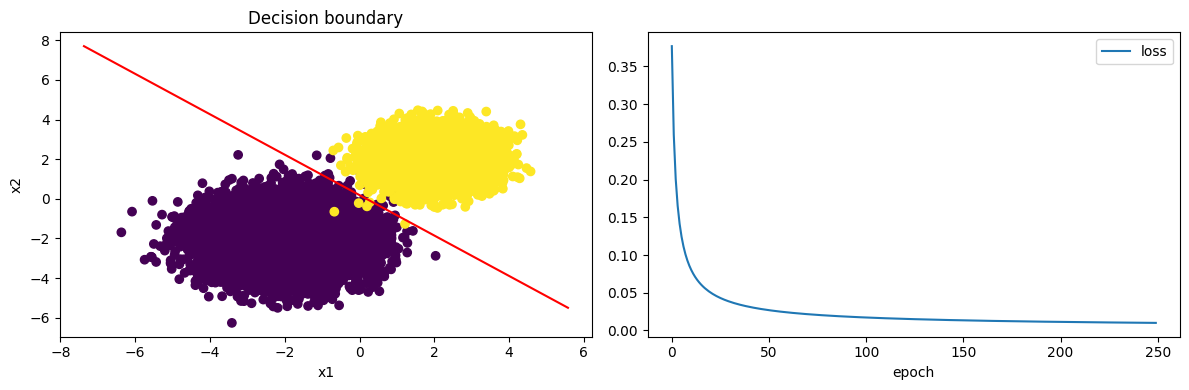

[-0.30730589  1.67281385  1.64159426] 0.010017400963498384


In [73]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(4)
n0 = 14253
n1 = 10276
X0 = np.random.normal(loc=[-2, -2], scale=1.0, size=(n0, 2))
X1 = np.random.normal(loc=[2, 2], scale=np.sqrt(0.5), size=(n1, 2))
X = np.vstack([X0, X1])
y = np.vstack([np.zeros((n0, 1)), np.ones((n1, 1))])
X_model = np.column_stack([np.ones(len(X)), X])

def sigmoid(z):
    return 1/(1+np.exp(-z))

def l(theta, X, y):
    p = sigmoid(X @ theta)
    return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()

def grad_l(theta, X, y):
    return (X.T @ (sigmoid(X @ theta) - y)) / len(y)

def accuracy(theta, X, y):
    preds = sigmoid(X @ theta) >= 0.5
    return (preds == y).mean()


def train_full_gd(X, y, lr, epochs):
    theta = np.zeros((X.shape[1], 1))
    losses = []
    for epoch in range(epochs):
        theta = theta - lr*grad_l(theta, X, y)
        losses.append(l(theta, X, y))
    return theta, np.array(losses),accuracy(theta, X, y)


theta, losses, acc = train_full_gd(X_model, y, lr=0.2, epochs=250)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X[:,0], X[:,1], c=y.ravel())
xx = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)
yy = -(theta[0,0] + theta[1,0]*xx)/theta[2,0]
axes[0].plot(xx, yy, color="red")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].set_title("Decision boundary")
axes[1].plot(losses, label="loss")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()



print(theta.ravel(), losses[-1])
# print(f"Final accuracy: {acc:.4f}")

## Exercise 2: SGD on Logistic Regression

Use the same synthetic dataset used in the previous exercise, but train logistic regression using **SGD** with the following choices:

1. Try different batch sizes:
   - $N_{\text{batch}} = 1$,
   - $N_{\text{batch}} = 10$,
   - $N_{\text{batch}} = N$ (full GD).

2. For each setting:
   - Plot the loss vs epoch,
   - Plot the classification accuracy vs epoch.

3. Compare the stability and speed of convergence over the choice of different batch sizes.

4. Why the gradients become noisier for small batches? Why larger batches give smoother curves?


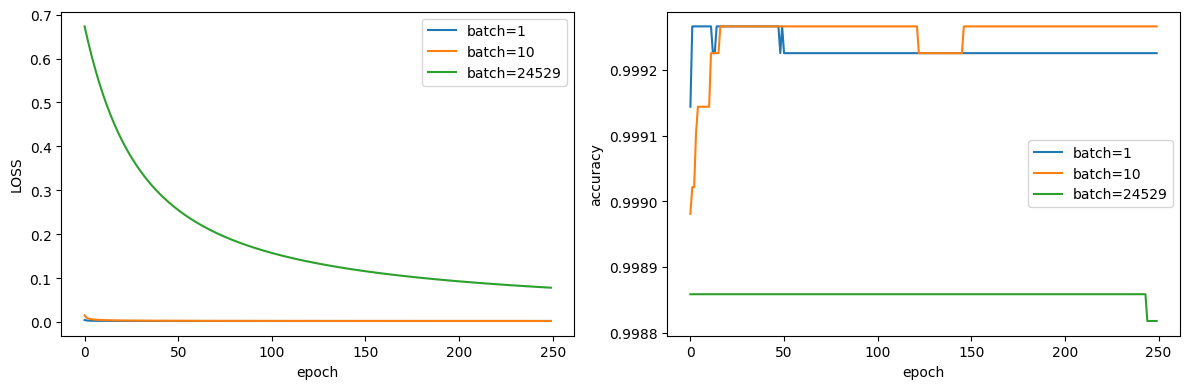

1 0.0025325865934587672 0.9992254066615027 [-2.55335142  4.56641057  3.5867019 ]
10 0.0025711333695034575 0.9992661747319499 [-2.15645892  4.03881075  3.30994774]
24529 0.07832069507247416 0.9988177259570304 [-0.06552088  0.71581993  0.71322002]


In [ ]:

np.random.seed(5)

def train_sgd(l, grad_l, X, y, lr=0.1, epochs=200, batch_size=32):
    N, d = X.shape
    theta = np.zeros((d, 1))
    losses, accs = [], []

    for epoch in range(epochs):
        # Shuffle data
        idx = np.arange(len(X))
        np.random.shuffle(idx)

        X = X[idx, :]
        y = y[idx]

        for batch in range(0, N, batch_size):
            grad = grad_l(theta, 
                             X[batch:batch + batch_size, :],
                             y[batch:batch + batch_size, :])
            theta -= lr * grad

        # Log full-dataset metrics after the epoch
        losses.append(l(theta, X, y))
        accs.append(accuracy(theta, X, y))

    return theta, np.array(losses), np.array(accs)


batch_sizes = [1, 10, len(y)]
results = {}
for batch_size in batch_sizes:
    np.random.seed(51)
    results[batch_size] = train_sgd(l, grad_l, X_model, y, 0.01, 250, batch_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for batch_size in batch_sizes:
    theta_sgd, losses_sgd, accs_sgd = results[batch_size]
    axes[0].plot(losses_sgd, label=f"batch={batch_size}")
    axes[1].plot(accs_sgd, label=f"batch={batch_size}")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("LOSS")
axes[0].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

for batch_size in batch_sizes:
    theta_sgd, losses_sgd, accs_sgd = results[batch_size]
    print(batch_size, losses_sgd[-1], accs_sgd[-1], theta_sgd.ravel())


## Exercise 3: Evaluation Metrics on a Synthetic Dataset

Using the logistic regression model trained above:

1. Compute predicted probabilities $\hat y_i = f_\Theta(x_i)$.
2. Convert them to binary predictions $\hat y_i \in \{0,1\}$ using threshold $0.5$.
3. Compute:
   - Confusion matrix (TP, FP, FN, TN),
   - Accuracy,
   - Precision,
   - Recall,
   - F1-score.

4. Modify the threshold to:
   - $0.3$,
   - $0.7$,
   and repeat.

5. Comment on:
   - How lower thresholds increase recall and lower precision,
   - How higher thresholds increase precision and reduce recall,
   - Why classification metrics depend on the application (as discussed in class).


In [75]:
import numpy as np

best_theta = results[10][0]

def metrics(theta, X, y, threshold):
    prob = sigmoid(X @ theta)
    pred = (prob >= threshold).astype(int)
    yy = y.astype(int)
    tp = int(np.sum((pred == 1) & (yy == 1)))
    fp = int(np.sum((pred == 1) & (yy == 0)))
    fn = int(np.sum((pred == 0) & (yy == 1)))
    tn = int(np.sum((pred == 0) & (yy == 0)))
    acc = (tp + tn)/(tp + tn + fp + fn)
    prec = tp/(tp + fp) if tp + fp > 0 else 0
    rec = tp/(tp + fn) if tp + fn > 0 else 0
    f1 = 2*prec*rec/(prec + rec) if prec + rec > 0 else 0
    return tp, fp, fn, tn, acc, prec, rec, f1

for threshold in [0.3, 0.5, 0.7]:
    print(threshold, metrics(best_theta, X_model, y, threshold))


0.3 (10271, 14, 5, 14239, 0.9992254066615027, 0.9986387943607195, 0.9995134293499416, 0.9990759204318856)
0.5 (10270, 12, 6, 14241, 0.9992661747319499, 0.9988329118848474, 0.9994161152199299, 0.999124428446347)
0.7 (10267, 9, 9, 14244, 0.9992661747319499, 0.9991241728298949, 0.9991241728298949, 0.9991241728298949)


## Exercise 4: Logistic Regression on a Real Dataset

Reproduce the pipeline from the book using the **Pima Indians Diabetes Dataset**, available at https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database.

This dataset contains medical measurements and a binary label indicating diabetes diagnosis.

1. Preprocess the data as done in class:
   - Download `diabetes.csv`.
   - Extract features $X$ and labels $y$.
   - **Standardize the features** (mean 0, variance 1).  
      Explain why normalization is required, connecting to:
      - conditioning,
      - stable optimization,
      - meaningful gradient magnitudes.

   - Add a bias column of 1s.

2. Implement logistic regression from scratch (sigmoid + BCE + gradient), and optimize using **SGD** with: 
   - a batch size of 32, a learning rate of $10^{-3}$, and 200 epochs.
   - for each epoch, track full-dataset BCE loss and full-dataset accuracy.
   - in a plot, visualize the behavior of Loss vs epoch and Accuracy vs epoch. Comment the results.

3. Train the same model using **Adam** (using the formulas from class):
   
   $$
   \Theta_{k+1} = \Theta_k - \eta \frac{\hat m_k}{\sqrt{\hat v_k} + \epsilon}.
   $$

   with a learning rate of $10^{-3}$, a batch size of 32, and 200 epochs. Then, plot SGD vs Adam loss and accuracy curves.

4. For each method, evaluate:
   - Final accuracy,
   - Confusion matrix,
   - Precision, Recall, F1.

5. Discuss on which method converge faster, which oscillate more, and how this relates to adaptive learning rates discussed in class.

### Optional Extension: From Logistic Regression to a Simple Neural Network

This optional section mirrors the final part of the supervised learning chapter.

Implement a neural network with:
- One hidden layer,
- ReLU activation,
- Sigmoid output layer.

You may reuse the implementation shown in the main text. Then:

1. Train the neural network on the **same** Kaggle dataset.
2. Track:
   - BCE loss vs epoch,
   - Accuracy vs epoch.
3. Compare and discuss the performance against logistic regression.

```{note}
This extension is *not mandatory* for passing the exam but can improve your understanding of model capacity.
```


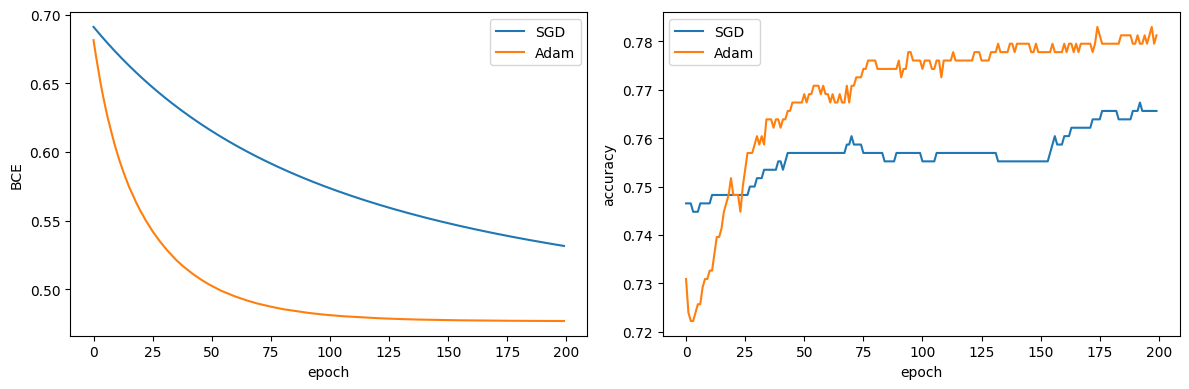

model          loss      acc    TP    FP    FN    TN     prec      rec       f1
--------------------------------------------------------------------------------------
SGD        0.497645   0.7760    35    11    32   114   0.7609   0.5224   0.6195
Adam       0.464034   0.7812    34     9    33   116   0.7907   0.5075   0.6182


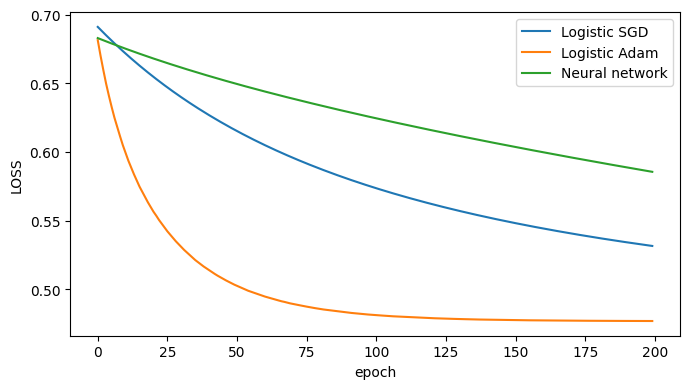

NN 0.585539448948578 0.6527777777777778


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(6)

def load_diabetes():
    path = Path("diabetes.csv")
    if path.exists():
        df = pd.read_csv(path)
        X = df.drop("Outcome", axis=1).values
        y = df["Outcome"].values.reshape(-1, 1)
        return X, y

X_raw, y_raw = load_diabetes()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.25, random_state=6, stratify=y_raw)
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma[sigma == 0] = 1
X_train = (X_train_raw - mu)/sigma
X_test = (X_test_raw - mu)/sigma
X_train = np.column_stack([np.ones(len(X_train)), X_train])
X_test = np.column_stack([np.ones(len(X_test)), X_test])

def train_sgd(l, grad_l, X, y, lr=1e-3, epochs=200, batch_size=32):
    N, d = X.shape
    theta = np.zeros((d, 1))
    losses, accs = [], []
    for epoch in range(epochs):
        # Shuffle data
        idx = np.arange(len(X))
        np.random.shuffle(idx)

        X = X[idx, :]
        y = y[idx]

        for batch in range(0, N, batch_size):
            grad = grad_l(theta, 
                             X[batch:batch + batch_size, :],
                             y[batch:batch + batch_size, :])
            theta -= lr * grad

        # Log full-dataset metrics after the epoch
        losses.append(l(theta, X, y))
        accs.append(accuracy(theta, X, y))

    return theta, np.array(losses), np.array(accs)

def train_adam(X, y, lr=1e-3, epochs=200, batch_size=32, beta1=0.9, beta2=0.999, eps=1e-8):
    theta = np.zeros((X.shape[1], 1))
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    t = 0
    losses = []
    accs = []
    n = len(y)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            g = grad_l(theta, X[batch], y[batch])
            t += 1
            m = beta1*m + (1-beta1)*g
            v = beta2*v + (1-beta2)*(g**2)
            m_hat = m/(1-beta1**t)
            v_hat = v/(1-beta2**t)
            theta = theta - lr*m_hat/(np.sqrt(v_hat) + eps)
        losses.append(l(theta, X, y))
        accs.append(accuracy(theta, X, y))
    return theta, np.array(losses), np.array(accs)

theta_sgd, loss_sgd, acc_sgd = train_sgd(l, grad_l, X_train, y_train)
theta_adam, loss_adam, acc_adam = train_adam(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_sgd, label="SGD")
axes[0].plot(loss_adam, label="Adam")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE")
axes[0].legend()
axes[1].plot(acc_sgd, label="SGD")
axes[1].plot(acc_adam, label="Adam")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


print(
    f"{'model':<8} "
    f"{'loss':>10} {'acc':>8} "
    f"{'TP':>5} {'FP':>5} {'FN':>5} {'TN':>5} "
    f"{'prec':>8} {'rec':>8} {'f1':>8}"
)
print("-" * 86)

for name, theta_eval in [("SGD", theta_sgd), ("Adam", theta_adam)]:
    test_loss = l(theta_eval, X_test, y_test)
    tp, fp, fn, tn, acc, prec, rec, f1 = metrics(
        theta_eval,
        X_test,
        y_test,
        threshold=0.5,
    )

    print(
        f"{name:<8} "
        f"{test_loss:10.6f} {acc:8.4f} "
        f"{tp:5d} {fp:5d} {fn:5d} {tn:5d} "
        f"{prec:8.4f} {rec:8.4f} {f1:8.4f}"
    )
rng = np.random.default_rng(7)

def train_nn(X, y, hidden=12, lr=1e-3, epochs=200, batch_size=32):
    n, d = X.shape
    W1 = rng.normal(0, 0.1, size=(d, hidden))
    b1 = np.zeros((1, hidden))
    W2 = rng.normal(0, 0.1, size=(hidden, 1))
    b2 = np.zeros((1, 1))
    losses = []
    accs = []
    for epoch in range(epochs):
        idx = rng.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            Xb = X[batch]
            yb = y[batch]
            z1 = Xb @ W1 + b1
            h = np.maximum(0, z1)
            p = sigmoid(h @ W2 + b2)
            dz2 = (p - yb)/len(yb)
            dW2 = h.T @ dz2
            db2 = dz2.sum(axis=0, keepdims=True)
            dh = dz2 @ W2.T
            dz1 = dh*(z1 > 0)
            dW1 = Xb.T @ dz1
            db1 = dz1.sum(axis=0, keepdims=True)
            W1 = W1 - lr*dW1
            b1 = b1 - lr*db1
            W2 = W2 - lr*dW2
            b2 = b2 - lr*db2
        p_full = sigmoid(np.maximum(0, X @ W1 + b1) @ W2 + b2)
        losses.append(-(y*np.log(np.clip(p_full, 1e-10, 1-1e-10)) + (1-y)*np.log(np.clip(1-p_full, 1e-10, 1-1e-10))).mean())
        accs.append(np.mean((p_full >= 0.5) == y))
    return (W1, b1, W2, b2), np.array(losses), np.array(accs)


rng = np.random.default_rng(71)
nn_params, nn_loss, nn_acc = train_nn(X_train, y_train, hidden=24)
plt.figure(figsize=(7, 4))
plt.plot(loss_sgd, label="Logistic SGD")
plt.plot(loss_adam, label="Logistic Adam")
plt.plot(nn_loss, label="Neural network")
plt.xlabel("epoch")
plt.ylabel("LOSS")
plt.legend()
plt.tight_layout()
plt.show()

print("NN", nn_loss[-1], nn_acc[-1])
